# Performance comparison

## TSP_POMO

data:
- `outputs/<algorithm>/tsp_pomo/results.json`

In [97]:
# Load data from output dir
from pathlib import Path
import json

current_dir = Path().resolve()
project_root = current_dir.parent

# TODO: set algorithms and problems to analysis
algorithms = ['reevo', 'eoh', 'ael', 'funsearch', 'oragent']
problem = 'tsp_pomo'

# read results.json and store in `results` dict
results = {}
for alg in algorithms:
    filepath = project_root / "outputs" / alg / problem / "results.json"
    with open(filepath, "r") as fp:
        results[alg] = json.load(fp)

for k, v in results.items():
    print(f"=====algorithm: {k}=====")
    for entry in v:
        print(entry)

=====algorithm: reevo=====
{'iteration': 0, 'total_responses': 0, 'total_function_evals': 1, 'total_valid_responses': 0, 'best_obj_overall': 22.00786781311035, 'metrics': {'200': 11.14848518371582, '500': 21.43581771850586, '1000': 33.439300537109375}, 'code_filepath': 'outputs/reevo/tsp_pomo/iter0_response0_solution.py', 'output_filepath': 'outputs/reevo/tsp_pomo/iter0_response0_stdout.txt'}
{'iteration': 1, 'total_responses': 20, 'total_function_evals': 21, 'total_valid_responses': 17, 'best_obj_overall': 21.447798093159992, 'metrics': {'200': 11.142830848693848, '500': 21.04697608947754, '1000': 32.153587341308594}, 'code_filepath': 'outputs/reevo/tsp_pomo/iter1_response19_solution.py', 'output_filepath': 'outputs/reevo/tsp_pomo/iter1_response19_stdout.txt'}
{'iteration': 2, 'total_responses': 40, 'total_function_evals': 31, 'total_valid_responses': 34, 'best_obj_overall': 21.285226504007976, 'metrics': {'200': 11.160061836242676, '500': 21.0532283782959, '1000': 31.64238929748535},

In [98]:
"""
plot a figure comparing the performance of algorithms

results[<algorithm_name>] is a list with entries:
 - iteration:
 - total_responses
 - total_function_evals
 - best_obj_overall
 - ...

Each entry is a record of the algorithm's best solution update.
Say, `results['eoh'][i]` means that `eoh` got a new best solution at iteration `results['eoh'][i]['iterations']`, when then total LLM responses is `results['eoh'][i]['total_responses']`, 
and total function evals is `results['eoh'][i]['total_function_evals']`; the newly best objective is `results['eoh'][i]['best_obj_overall']`.

Use matplotlib.
The figure axes:
x-axis: total_responses;
y-axis: best_obj_overall

Plot curves: one for each algorithm.

Note: each algorithm has is own total_responses range; set the xlim to be bounded by the smallest one.
"""

"\nplot a figure comparing the performance of algorithms\n\nresults[<algorithm_name>] is a list with entries:\n - iteration:\n - total_responses\n - total_function_evals\n - best_obj_overall\n - ...\n\nEach entry is a record of the algorithm's best solution update.\nSay, `results['eoh'][i]` means that `eoh` got a new best solution at iteration `results['eoh'][i]['iterations']`, when then total LLM responses is `results['eoh'][i]['total_responses']`, \nand total function evals is `results['eoh'][i]['total_function_evals']`; the newly best objective is `results['eoh'][i]['best_obj_overall']`.\n\nUse matplotlib.\nThe figure axes:\nx-axis: total_responses;\ny-axis: best_obj_overall\n\nPlot curves: one for each algorithm.\n\nNote: each algorithm has is own total_responses range; set the xlim to be bounded by the smallest one.\n"

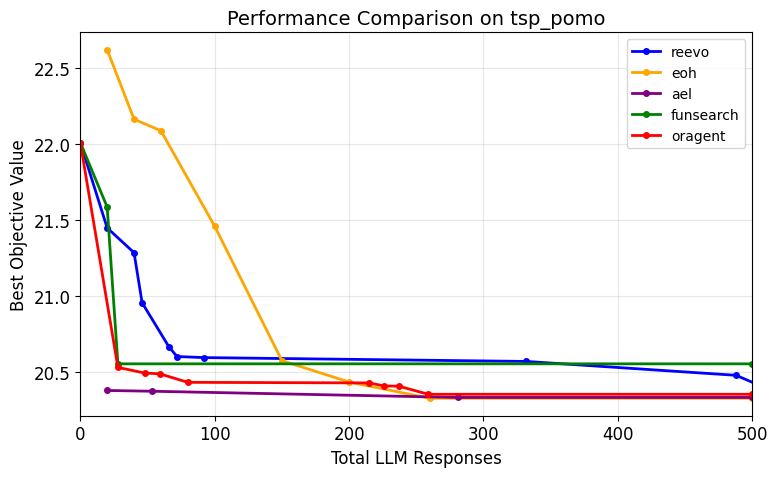

In [99]:
from plotlib import color_scheme, font_scheme


performance_index = 'total_responses'
x_label = 'Total LLM Responses'

    
# =====x-axis limit based on largest total_responses range=====
min_x = 0
max_x = 0
for alg in algorithms:
    if alg in results:
        alg_responses = [entry[performance_index] for entry in results[alg]]
        if alg_responses:
            max_x = max(max_x, max(alg_responses))

# manually set the x-lim
max_x = 500


# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for alg in algorithms:
        last_entry = deepcopy(results[alg][-1])
        if last_entry[performance_index] < max_x:
            last_entry[performance_index] = max_x
            results[alg].append(last_entry)


# =====Plot=====
import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

# Create figure
plt.figure(figsize=(8, 5))

# Plot each algorithm
for alg in algorithms:
    if alg in results:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[alg]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[alg]]
        
        # Plot the curve
        plt.plot(total_responses, best_obj_overall, marker='o', markersize=4, label=alg, linewidth=2, color=color_scheme[alg])

plt.xlim(min_x, max_x)

# Add labels and legend
plt.xlabel(x_label, fontsize=12)
plt.ylabel('Best Objective Value', fontsize=12)
plt.title(f'Performance Comparison on {problem}', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()

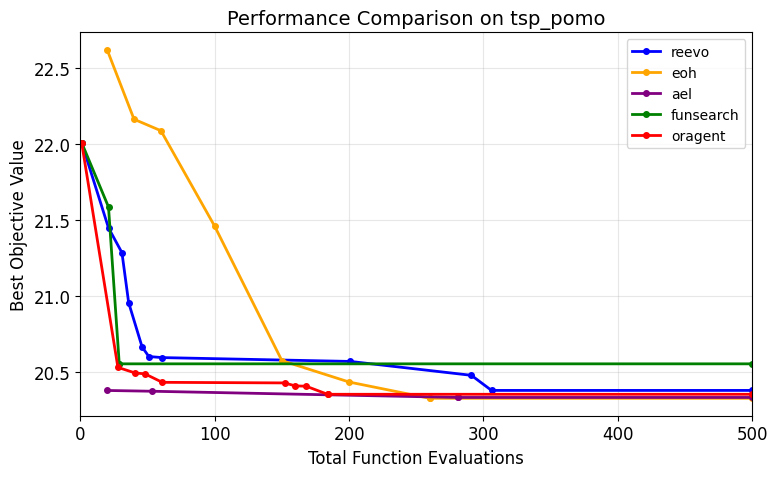

In [100]:
from plotlib import color_scheme, font_scheme


performance_index = 'total_function_evals'
x_label = 'Total Function Evaluations'


# =====x-axis limit based on largest total_responses range=====
min_x = 0
max_x = 0
for alg in algorithms:
    if alg in results:
        alg_responses = [entry[performance_index] for entry in results[alg]]
        if alg_responses:
            max_x = max(max_x, max(alg_responses))

# manually set the x-lim
max_x = 500


# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for alg in algorithms:
        last_entry = deepcopy(results[alg][-1])
        if last_entry[performance_index] < max_x:
            last_entry[performance_index] = max_x
            results[alg].append(last_entry)
    
    
# =====Plot=====
import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

# Create figure
plt.figure(figsize=(8, 5))

# Plot each algorithm
for alg in algorithms:
    if alg in results:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[alg]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[alg]]
        
        # Plot the curve
        plt.plot(total_responses, best_obj_overall, marker='o', markersize=4, label=alg, linewidth=2, color=color_scheme[alg])

plt.xlim(min_x, max_x)

# Add labels and legend
plt.xlabel(x_label, fontsize=12)
plt.ylabel('Best Objective Value', fontsize=12)
plt.title(f'Performance Comparison on {problem}', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()